# Resnet Model

## Installing libraries

In [1]:
pip install -q ptflops

In [38]:
import numpy as np
import torch
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
from sklearn.svm import SVC
import time
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [39]:
from torchvision import datasets, transforms, models

In [40]:
from ptflops import get_model_complexity_info

## Preprocessing

In [72]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

mnist = datasets.MNIST(root = './data', train = True, download= True, transform = transform)
fashion_mnist = datasets.FashionMNIST(root = './data',train = True, download = True, transform = transform)

In [73]:
train_mnist = int(0.7*len(mnist))
val_mnist = int(0.1*len(mnist))
test_mnist = int(0.2*len(mnist))

train_ds,val_ds,test_ds = random_split(mnist,[train_mnist,val_mnist,test_mnist])

In [74]:
train_fmnist = int(0.7*len(mnist))
val_fmnist = int(0.1*len(mnist))
test_fmnist = int(0.2*len(mnist))

ftrain_ds,fval_ds,ftest_ds = random_split(fashion_mnist,[train_fmnist,val_fmnist,test_fmnist])

In [75]:
batch_size = 16
pin_memory = True
lr = 0.001

In [76]:
train_loader = DataLoader(train_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory,num_workers = 2)
val_loader = DataLoader(val_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory,num_workers = 2)
test_loader = DataLoader(test_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory,num_workers = 2)

In [77]:
ftrain_loader = DataLoader(ftrain_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory)
fval_loader = DataLoader(fval_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory)
ftest_loader = DataLoader(ftest_ds,batch_size = batch_size, shuffle = True, pin_memory = pin_memory)

## Model calling

In [78]:
model_resnet18 = models.resnet18(pretrained = False)
model_resnet34 = models.resnet34(pretrained = False)
model_resnet50 = models.resnet50(pretrained = False)

model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features,10)
model_resnet34.fc = nn.Linear(model_resnet34.fc.in_features,10)
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features,10)

In [79]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_resnet18 = model_resnet18.to(device)
model_resnet34 = model_resnet34.to(device)
model_resnet50 = model_resnet50.to(device)

In [80]:
criterion = nn.CrossEntropyLoss()

model_resnet18_optimizer_Adam = optim.Adam(model_resnet18.parameters(), lr=lr)
model_resnet34_optimizer_Adam = optim.Adam(model_resnet34.parameters(), lr=lr)
model_resnet50_optimizer_Adam = optim.Adam(model_resnet50.parameters(), lr=lr)

model_resnet18_optimizer_SGD = optim.SGD(model_resnet18.parameters(), lr=lr)
model_resnet34_optimizer_SGD = optim.SGD(model_resnet34.parameters(), lr=lr)
model_resnet50_optimizer_SGD = optim.SGD(model_resnet50.parameters(), lr=lr)

## Training

In [100]:
class model:
  def __init__(self):

    self.train_losses = []
    self.val_losses = []

    self.train_accuracies = []
    self.val_accuracies = []

  def compute_accuracy(self, model = model_resnet18, loader = train_loader,device = device):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loss_sum += loss.item() * labels.size(0)

    avg_loss = loss_sum / total
    accuracy = 100.0 * correct / total

    return avg_loss, accuracy

  def train(self, model = model_resnet18, optimizer = model_resnet18_optimizer_Adam, epochs = 3,dataset = 'MNIST'):

    self.epochs = epochs

    if dataset in ['MNIST','mnist']:
      loader = train_loader
    elif dataset in ['f_MNIST','fashion_MNIST','Fashion_MNIST']:
      loader = ftrain_loader

    scaler = GradScaler()  # AMP enabled

    #Learning start

    start = time.time()

    for epoch in range(epochs):
      model.train()
      running_loss = 0.0
      correct = 0
      total = 0

      for images, labels in loader:
          images, labels = images.to(device), labels.to(device)

          optimizer.zero_grad()

          outputs = model(images)
          loss = criterion(outputs, labels)

          loss.backward()
          optimizer.step()

          running_loss += loss.item() * labels.size(0)
          _, preds = torch.max(outputs, 1)
          correct += (preds == labels).sum().item()
          total += labels.size(0)

      train_loss = running_loss / total
      train_acc = 100.0 * correct / total

      if dataset in ['MNIST','mnist']:
        val_loss, val_acc = self.compute_accuracy(model, val_loader, device)
      elif dataset in ['f_MNIST','fashion_MNIST','Fashion_MNIST']:
        val_loss, val_acc = self.compute_accuracy(model, fval_loader, device)

      self.train_losses.append(train_loss)
      self.val_losses.append(val_loss)
      self.train_accuracies.append(train_acc)
      self.val_accuracies.append(val_acc)

      print(
          f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
      )


    end = time.time()

    train_time_ms = (end - start) * 1000
    return 'Training time:',train_time_ms

  def plot(self):

    epochs_range = range(1, self.epochs + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, self.train_losses, label="Train Loss")
    plt.plot(epochs_range, self.val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, self.train_accuracies, label="Train Accuracy")
    plt.plot(epochs_range, self.val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Train vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

  def compute(self, model = model_resnet18):
    with torch.cuda.device(0):
      flops, params = get_model_complexity_info(
          model,
          (3, 28, 28),
          as_strings=True,
          print_per_layer_stat=False
      )

    print("FLOPs:", flops)
    print("Params:", params)

In [101]:
Model = model()

In [102]:
Model.train(model = model_resnet18, optimizer = model_resnet18_optimizer_Adam, epochs = 3,dataset = 'MNIST')

Epoch [1/3] Train Loss: 0.0255 | Train Acc: 99.27% Val Loss: 0.0404 | Val Acc: 99.02%
Epoch [2/3] Train Loss: 0.0241 | Train Acc: 99.36% Val Loss: 0.0326 | Val Acc: 99.17%
Epoch [3/3] Train Loss: 0.0183 | Train Acc: 99.46% Val Loss: 0.0559 | Val Acc: 98.35%


('Training time:', 147323.3871459961)

## Result

In [103]:
Model.compute_accuracy(model = model_resnet18,loader = test_loader,device = device)

(0.05505832603510134, 98.5)

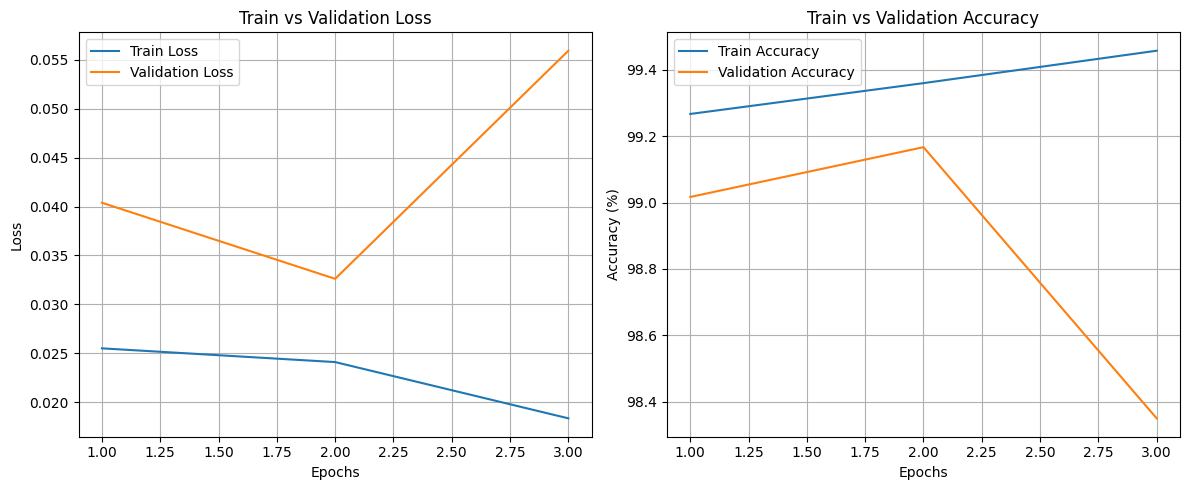

In [104]:
Model.plot()

In [71]:
Model.compute()

FLOPs: 34.43 MMac
Params: 11.18 M


# SVM Model

## Preprocessing

In [19]:
transform = transforms.ToTensor()

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

fashion_train = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
fashion_test  = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

In [20]:
def dataset_to_numpy(dataset):
  x = []
  y = []
  for img,label in dataset:
    x.append(img.flatten())
    y.append(label)
  return np.array(x),np.array(y)

In [21]:
X_train_mnist, y_train_mnist = dataset_to_numpy(mnist_train)
X_test_mnist, y_test_mnist = dataset_to_numpy(mnist_test)

X_train_fashion, y_train_fashion = dataset_to_numpy(fashion_train)
X_test_fashion, y_test_fashion = dataset_to_numpy(fashion_test)

##Model

In [22]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")

start = time.time()
svm_rbf.fit(X_train_mnist, y_train_mnist)
end = time.time()

train_time_ms = (end - start) * 1000
accuracy = svm_rbf.score(X_test_mnist, y_test_mnist) * 100

In [23]:
print(f"RBF SVM MNIST Accuracy: {accuracy:.2f}%")
print(f"Training Time: {train_time_ms:.2f} ms")

RBF SVM MNIST Accuracy: 97.92%
Training Time: 231224.36 ms


In [24]:
svm_poly = SVC(kernel="poly", degree=3, C=1.0, gamma="scale")

start = time.time()
svm_poly.fit(X_train_mnist, y_train_mnist)
end = time.time()

train_time_ms = (end - start) * 1000
accuracy = svm_poly.score(X_test_mnist, y_test_mnist) * 100

In [25]:
print(f"poly SVM MNIST Accuracy: {accuracy:.2f}%")
print(f"Training Time: {train_time_ms:.2f} ms")

poly SVM MNIST Accuracy: 97.71%
Training Time: 228624.15 ms
